# Study 1: Simple Linear Regression

Reference: https://oraprdnt.uqtr.uquebec.ca/Gscdepot/paf1010/19/M13.pdf


Import the libraries: numpy, pandas, matplotlib, ...


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

plots_dir = Path("../../plots/etude1_RLsimple")
plots_dir.mkdir(parents=True, exist_ok=True)


## Part 1 - A First Dataset


### Data Import and Exploratory Analysis


1) Read the file dataset1.csv as a data table using pandas and display the first 5 rows of the table

Hint: read_csv, head


In [2]:
df1 = pd.read_csv("dataset1.csv", sep=";")
df1.head()


,x,y
0,0,46.357215
1,1,46.080189
2,2,45.077372
3,3,48.480649
4,4,43.666733


2) Display a concise summary of the DataFrame to understand the data: columns, number of non-null elements, and data types.

Hint: info


In [3]:
df1.info()


<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       26 non-null     int64  
 1   y       26 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 548.0 bytes


3) Produce descriptive statistics for the dataset: max, min, mean, etc.

Hint: describe


In [4]:
df1.describe()


,x,y
count,26.000000,26.000000
mean,12.500000,27.604172
std,7.648529,12.549125
min,0.000000,6.242566
25%,6.250000,17.853984
50%,12.500000,27.263529
75%,18.750000,35.945827
max,25.000000,48.480649


4. Plot y(x) as a scatter plot.

Hint: scatter (matplotlib)


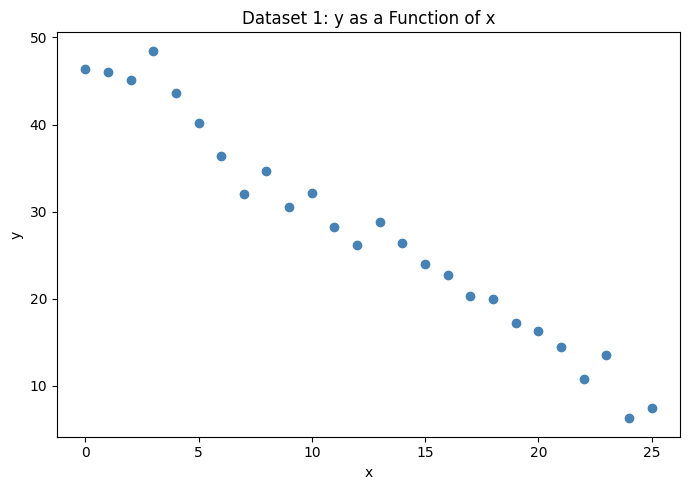

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df1["x"], df1["y"], color="steelblue")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Dataset 1: y as a Function of x")
fig.tight_layout()
fig.savefig(plots_dir / "01_dataset1_scatter.pdf", bbox_inches="tight")
plt.show()


5. Justify the choice of a simple linear regression model for prediction.


Answer: The scatter plot shows an approximately straight-line trend between x and y. Because there is one explanatory variable and one quantitative target, a simple linear regression model is an appropriate first model.


### Building the Simple Linear Regression Model


6. Identify the independent variable and the dependent variable in the dataset. Then extract both variables in DataFrame/Series format.


In [6]:
x = df1[["x"]]
y = df1["y"]
print("Independent variable: x")
print("Dependent variable: y")
display(x.head())
display(y.head())


Independent variable: x
Dependent variable: y


,x
0,0
1,1
2,2
3,3
4,4


0    46.357215
1    46.080189
2    45.077372
3    48.480649
4    43.666733
Name: y, dtype: float64

To build the simple LR (linear regression) model y = w0 + w1*x, we need to determine the coefficients:
* w0: intercept
* w1: slope

We use the ordinary least squares (OLS) method.

Reference: https://perso.lpsm.paris/~aguyader/files/teaching/Regression.pdf (chapter 1)


7. Complete the following code (OLS function).


In [7]:
def compute_coefficient(x, y):
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()
    n = len(x)
    x_mean = np.mean(x)
    y_mean = np.mean(y)

    numerator = 0
    denominator = 0

    for i in range(n):
        numerator += (x[i] - x_mean) * (y[i] - y_mean)
        denominator += (x[i] - x_mean) ** 2

    # Calculate coefficients
    slope = numerator / denominator
    intercept = y_mean - slope * x_mean

    return slope, intercept


8) Training phase

This consists of determining the coefficients w0 and w1 from the dataset.


In [8]:
slope_ols, intercept_ols = compute_coefficient(x, y)
print(f"w0/intercept = {intercept_ols:.6f}")
print(f"w1/slope     = {slope_ols:.6f}")


w0/intercept = 47.839382
w1/slope     = -1.618817


Note:

The function "LinearRegression" in the Scikit-Learn library https://scikit-learn.org/stable/ does the same thing.

https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html


9. Train with the LR model in Scikit-Learn.

Comment on the following code by explaining what each line does.

Run the code.

The code does not work as written: explain and correct it.


In [9]:
# LinearRegression creates a linear model object.
model_RL = LinearRegression()

# fit trains the model. X must be two-dimensional, so we use x as a DataFrame.
model_RL.fit(x, y)

# The original code fails if x is passed as a one-dimensional Series.
# Keeping x = df1[["x"]] fixes the shape expected by Scikit-Learn.
model_RL


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


10. Display the coefficients w0 and w1 and compare them with those obtained in question 8.

Hint: intercept_, coef_


In [10]:
print(f"Scikit-Learn w0/intercept = {model_RL.intercept_:.6f}")
print(f"Scikit-Learn w1/slope     = {model_RL.coef_[0]:.6f}")
print(f"OLS w0/intercept          = {intercept_ols:.6f}")
print(f"OLS w1/slope              = {slope_ols:.6f}")


Scikit-Learn w0/intercept = 47.839382
Scikit-Learn w1/slope     = -1.618817
OLS w0/intercept          = 47.839382
OLS w1/slope              = -1.618817


#### Important note:
Before developing your own Machine Learning functions, get into the habit of looking for existing solutions. They are often the result of expert work, optimized and robust thanks to community feedback. This saves time, avoids common errors, and gives you access to quality code. The main objective of question 7 is to illustrate the model training process pedagogically.


### Prediction Using the Trained LR Model


11. Use the model model_RL to make the prediction:
* Input: x
* Output: named ypred


In [11]:
ypred = model_RL.predict(x)
ypred[:5]


array([47.83938222, 46.22056538, 44.60174854, 42.9829317 , 41.36411486])

12. Give the definition and then determine the score, MSE, RMSE, MAE, and MAPE errors of model_RL.

Reference: https://kobia.fr/regression-metrics-quelle-metrique-choisir/


Answer:

Definitions:
* Score: coefficient of determination R², the share of target variance explained by the model.
* MSE: mean squared error, the average of squared prediction errors.
* RMSE: square root of MSE, expressed in the same unit as the target.
* MAE: mean absolute error, the average absolute prediction error.
* MAPE: mean absolute percentage error, the average relative absolute error.


In [12]:
score = model_RL.score(x, y)
mse = mean_squared_error(y, ypred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, ypred)
mape = mean_absolute_percentage_error(y, ypred)

metrics_df1 = pd.DataFrame({
    "metric": ["R2 score", "MSE", "RMSE", "MAE", "MAPE"],
    "value": [score, mse, rmse, mae, mape],
})
metrics_df1


,metric,value
0,R2 score,0.973474
1,MSE,4.016645
2,RMSE,2.004157
3,MAE,1.472374
4,MAPE,0.068585


Comment on the accuracy of the model and the initial choice of the LR model.


Answer: The numerical metrics and the plot show whether the linear trend explains the data well. If R² is high and the errors remain small relative to y, the initial simple linear regression choice is justified.


13. Plot the data scatter plot and draw the line given by the model.


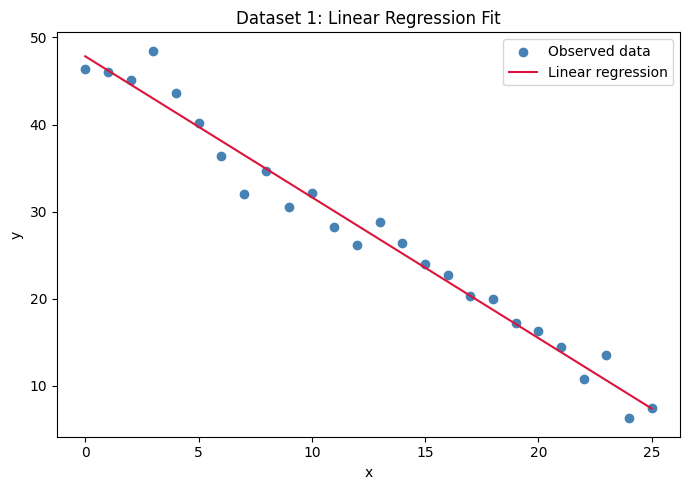

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x["x"], y, label="Observed data", color="steelblue")
ax.plot(x["x"], ypred, label="Linear regression", color="crimson")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Dataset 1: Linear Regression Fit")
ax.legend()
fig.tight_layout()
fig.savefig(plots_dir / "02_dataset1_regression_line.pdf", bbox_inches="tight")
plt.show()


14. Estimate y for x = 20.5.


In [14]:
x_new = pd.DataFrame({"x": [20.5]})
y_new_pred = model_RL.predict(x_new)[0]
print(f"Predicted y for x = 20.5: {y_new_pred:.4f}")


Predicted y for x = 20.5: 14.6536


15. Put this point on the previous graph.


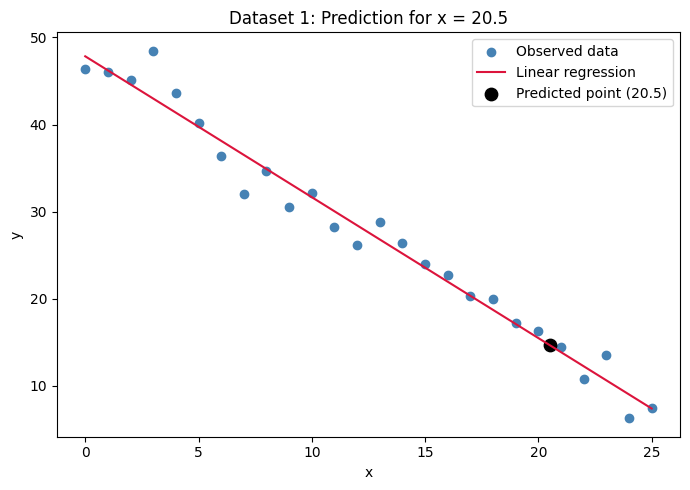

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x["x"], y, label="Observed data", color="steelblue")
ax.plot(x["x"], ypred, label="Linear regression", color="crimson")
ax.scatter(x_new["x"], [y_new_pred], color="black", s=80, label="Predicted point (20.5)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Dataset 1: Prediction for x = 20.5")
ax.legend()
fig.tight_layout()
fig.savefig(plots_dir / "03_dataset1_prediction_20_5.pdf", bbox_inches="tight")
plt.show()


#### Important note:
This new data point is particularly interesting because it is not represented in the training set. A prediction on this point lets us evaluate the model’s ability to generalize to unseen situations more precisely.


16. Can we evaluate the prediction accuracy for this new point?


Answer: Not directly, because we do not know the true observed value of y for x = 20.5. We can only give the model prediction and compare it later if a true value becomes available.


17. What is your solution for evaluating the model’s ability to generalize to unseen situations?


Answer: Keep aside a test set that is not used during training, or use cross-validation. The model is trained on one part of the data and evaluated on unseen observations with known target values.


## Part 2 - Another Dataset - Train/Test Split


18. Import dataset2.csv and perform exploratory analyses as in part 1.


,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
0,1,1,4512,1530
1,1,1,3738,1297
2,1,1,4261,1335
3,1,1,3777,1282
4,1,1,4177,1590


<class 'pandas.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Gender               237 non-null    int64
 1   Age Range            237 non-null    int64
 2   Head Size(cm^3)      237 non-null    int64
 3   Brain Weight(grams)  237 non-null    int64
dtypes: int64(4)
memory usage: 7.5 KB


None

,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
count,237.000000,237.000000,237.000000,237.000000
mean,1.434599,1.535865,3633.991561,1282.873418
std,0.496753,0.499768,365.261422,120.340446
min,1.000000,1.000000,2720.000000,955.000000
25%,1.000000,1.000000,3389.000000,1207.000000
50%,1.000000,2.000000,3614.000000,1280.000000
75%,2.000000,2.000000,3876.000000,1350.000000
max,2.000000,2.000000,4747.000000,1635.000000


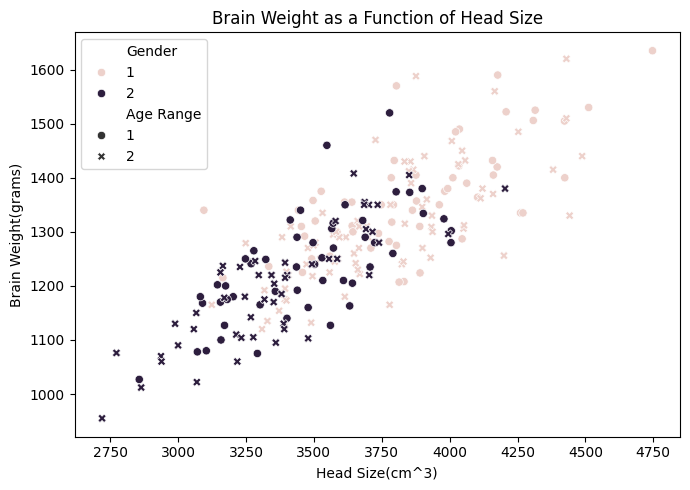

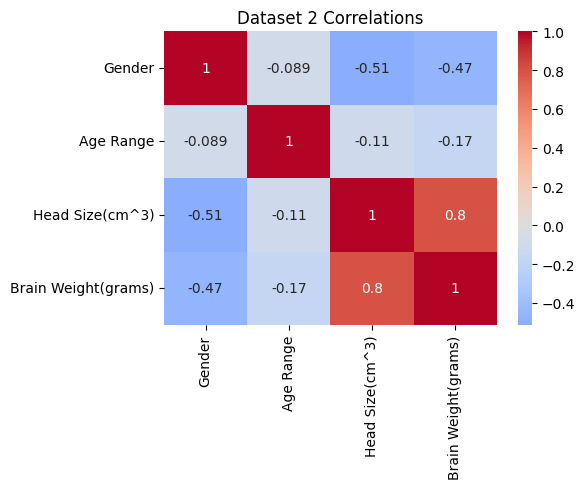

In [16]:
df2 = pd.read_csv("dataset2.csv")
display(df2.head())
display(df2.info())
display(df2.describe())

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df2, x="Head Size(cm^3)", y="Brain Weight(grams)", hue="Gender", style="Age Range", ax=ax)
ax.set_title("Brain Weight as a Function of Head Size")
fig.tight_layout()
fig.savefig(plots_dir / "04_dataset2_scatter.pdf", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df2.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Dataset 2 Correlations")
fig.tight_layout()
fig.savefig(plots_dir / "05_dataset2_correlation_heatmap.pdf", bbox_inches="tight")
plt.show()


19. Can we use the simple LR model to predict brain weight from head size? Justify.


Answer: Yes, as a first model. The scatter plot shows a positive roughly linear relationship between head size and brain weight, so simple linear regression is relevant. The relationship is not perfect, so the residual metrics must be checked.


20. Build an LR model using Scikit-Learn.


In [17]:
X2 = df2[["Head Size(cm^3)"]]
y2 = df2["Brain Weight(grams)"]
model_RL2 = LinearRegression()
model_RL2.fit(X2, y2)
print(f"Intercept: {model_RL2.intercept_:.4f}")
print(f"Slope: {model_RL2.coef_[0]:.4f}")


Intercept: 325.5734
Slope: 0.2634


21. Train this model on different train/test partitions using the following ratios:
* 20% train / 80% test
* 50% train / 50% test
* 80% train / 20% test

The partitions will be created while preserving the order of appearance in the dataset.

For each partition, display the metrics: score, MSE, RMSE, MAE, and MAPE for train and then for test.

Compare and comment on the results.


,split,R2_score,MSE,RMSE,MAE,MAPE,train_ratio
0,train,0.449474,5538.650576,74.422111,58.642882,0.042699,0.2
1,test,0.343214,8354.852635,91.404883,75.027766,0.061954,0.2
2,train,0.520300,5753.927680,75.854648,58.738278,0.043842,0.5
3,test,0.526726,5165.682738,71.872684,57.769227,0.048064,0.5
4,train,0.572666,5593.061421,74.786773,58.348267,0.044677,0.8
5,test,0.649121,3880.492241,62.293597,49.993843,0.042779,0.8


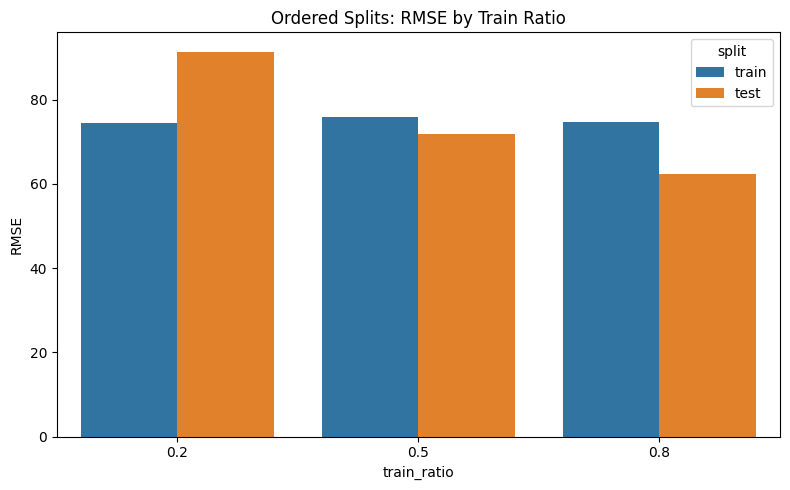

Comment: the ordered split can give unstable results because the first and last rows may not represent the same distribution. The 80/20 split generally trains on more information, but the test metric still depends strongly on which rows are held out.


In [18]:
def regression_metrics(model, X_train, X_test, y_train, y_test):
    rows = []
    for split_name, X_part, y_part in [
        ("train", X_train, y_train),
        ("test", X_test, y_test),
    ]:
        pred = model.predict(X_part)
        mse = mean_squared_error(y_part, pred)
        rows.append({
            "split": split_name,
            "R2_score": r2_score(y_part, pred),
            "MSE": mse,
            "RMSE": np.sqrt(mse),
            "MAE": mean_absolute_error(y_part, pred),
            "MAPE": mean_absolute_percentage_error(y_part, pred),
        })
    return rows

ordered_results = []
for train_ratio in [0.2, 0.5, 0.8]:
    split_index = int(len(df2) * train_ratio)
    X_train_ord = X2.iloc[:split_index]
    X_test_ord = X2.iloc[split_index:]
    y_train_ord = y2.iloc[:split_index]
    y_test_ord = y2.iloc[split_index:]

    model = LinearRegression().fit(X_train_ord, y_train_ord)
    for row in regression_metrics(model, X_train_ord, X_test_ord, y_train_ord, y_test_ord):
        row["train_ratio"] = train_ratio
        ordered_results.append(row)

ordered_results_df = pd.DataFrame(ordered_results)
display(ordered_results_df)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=ordered_results_df, x="train_ratio", y="RMSE", hue="split", ax=ax)
ax.set_title("Ordered Splits: RMSE by Train Ratio")
fig.tight_layout()
fig.savefig(plots_dir / "06_dataset2_ordered_split_rmse.pdf", bbox_inches="tight")
plt.show()

print("Comment: the ordered split can give unstable results because the first and last rows may not represent the same distribution. The 80/20 split generally trains on more information, but the test metric still depends strongly on which rows are held out.")


To ensure statistical representativeness of the training set, it is common to randomly split the data into training and test sets.

Random data splitting can be done with train_test_split: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html#sklearn.model_selection.train_test_split


22. Optional question: redo question 21 with this new approach and comment on the results obtained.


,split,R2_score,MSE,RMSE,MAE,MAPE,train_ratio
0,train,0.710394,3387.469594,58.201972,44.717353,0.036138,0.2
1,test,0.620169,5664.650541,75.263873,59.381216,0.046000,0.2
2,train,0.658002,4567.766787,67.585256,50.223741,0.039387,0.5
3,test,0.620841,5854.404394,76.514080,62.682403,0.048777,0.5
4,train,0.639239,5202.522632,72.128515,55.545407,0.043231,0.8
5,test,0.637636,5200.615466,72.115293,59.714834,0.046604,0.8


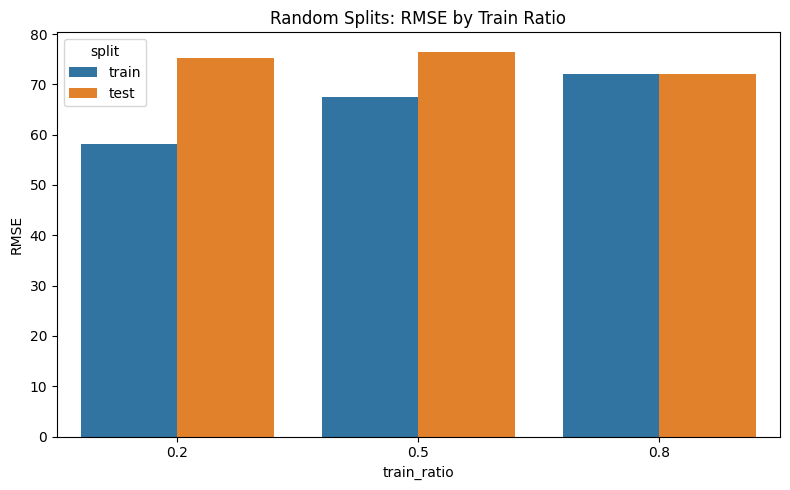

Comment: random splitting is more representative than preserving row order. The train/test scores are closer and give a more credible estimate of generalization.


In [19]:
random_results = []
for train_ratio in [0.2, 0.5, 0.8]:
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X2, y2, train_size=train_ratio, random_state=0
    )
    model = LinearRegression().fit(X_train_r, y_train_r)
    for row in regression_metrics(model, X_train_r, X_test_r, y_train_r, y_test_r):
        row["train_ratio"] = train_ratio
        random_results.append(row)

random_results_df = pd.DataFrame(random_results)
display(random_results_df)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=random_results_df, x="train_ratio", y="RMSE", hue="split", ax=ax)
ax.set_title("Random Splits: RMSE by Train Ratio")
fig.tight_layout()
fig.savefig(plots_dir / "07_dataset2_random_split_rmse.pdf", bbox_inches="tight")
plt.show()

print("Comment: random splitting is more representative than preserving row order. The train/test scores are closer and give a more credible estimate of generalization.")
